In [112]:
import glob

import icechunk
import matplotlib.pyplot as plt
import pandas as pd
import zarr

from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.qaqc import (
    disagg_test_calculate_metrics,
    disagg_test_plot_summary_stats,
    disagg_test_print_all_evaluation_metrics,
)
from srm.utils import open_icechunk

# 0. Look at one variable, scenario, ensemble combo

## Get data

In [87]:
path_output = (
    "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
var = "tasmin"
scenario = "g6_1p5k"
ens = "003"

In [88]:
storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",
    prefix="srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch="qa-qc-downscaling-step/vtest01")
root = zarr.open_group(session.store, mode="r")
print(root.tree())

{'timing-after', 'tasmin-tasmax-fix', 'qa-qc-downscaling-step/vtest01', 'tasmin-tasmax-fix-v4', 'v0.7.0.post6', 'tasmin-tasmax-fix-v3', 'tasmin-tasmax-fix-v2', 'main'}
/
├── debiased_coarse
│   ├── g6_1p5k
│   │   ├── dtr
│   │   │   └── 003
│   │   │       ├── dtr (25568, 14, 14) float32
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       └── time (25568,) int64
│   │   ├── hurs
│   │   │   └── 003
│   │   │       ├── hurs (25568, 14, 14) float32
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       └── time (25568,) int64
│   │   ├── pr
│   │   │   └── 003
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       ├── pr (25568, 14, 14) float32
│   │   │       └── time (25568,) int64
│   │   ├── rsds
│   │   │   └── 003
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       ├── rsds (25568, 14, 14) float32
│   │   │       └── time (25568,

In [89]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch="qa-qc-downscaling-step/vtest01",
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)
debiased_downscaled = open_icechunk(
    path=path_output,
    branch="qa-qc-downscaling-step/vtest01",
    group=scenario + "/" + var + "/" + ens,
)

In [90]:
output_prefix = path_qaqc + "disagg_tests_" + var + "_" + scenario + "_" + ens

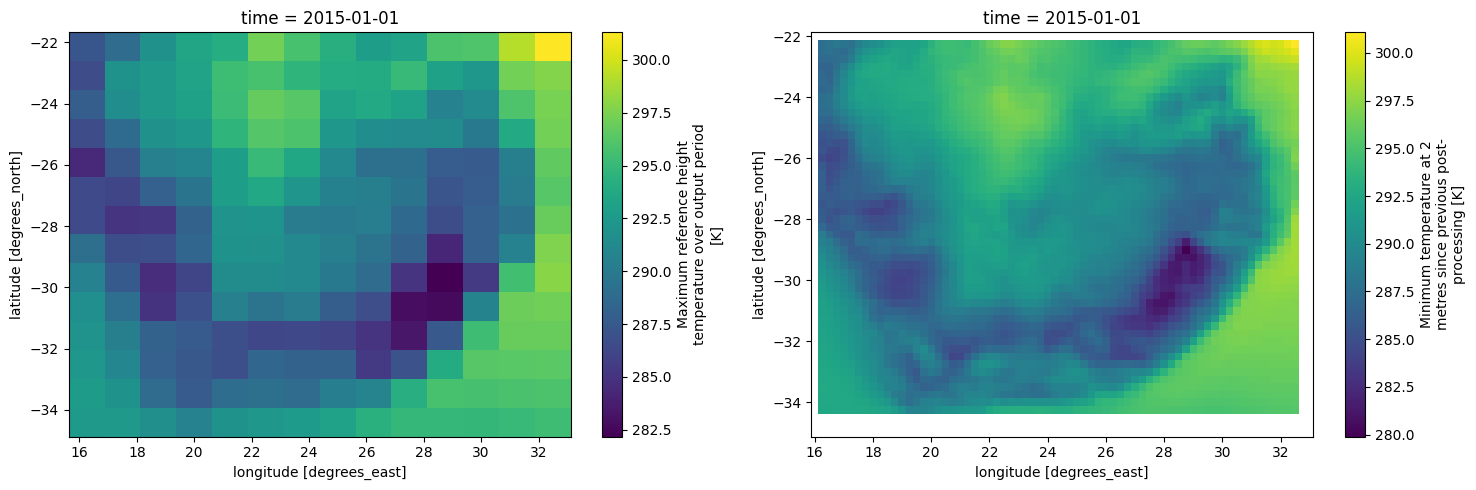

In [91]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
coarse_debiased[var].isel(time=0).plot()
plt.subplot(1, 2, 2)
debiased_downscaled[var].isel(time=0).plot()
plt.tight_layout()

## Re-coarsen debiased, downscaled data
Ideally, the spatial disaggregation step should spread out data in the coarse grid cell, but not actually change the coarse average. So if we recoarsen the downscaled, debiased data, ideally it would be the same as the debiased, coarse data, and this should be true at every point in time. However, the Thrasher implementation of BCSD does not guarantee that this is the case mathematically, so we need to evaluate how much the downscaling changes the answer.

In [92]:
debiased_downscaled_coarsened = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=debiased_downscaled[var], da_coarse_grid=coarse_debiased[var]
)

In [93]:
# Step 1: resample to monthly means
monthly = debiased_downscaled_coarsened.resample(time="MS").mean()

# Step 2: for each calendar month, apply a 10-year trailing rolling mean
debiased_downscaled_coarsened_monthly_smooth = (
    monthly.groupby("time.month")
    .map(lambda da: da.rolling(time=10, min_periods=10).mean())
    .sortby("time")
)

# Step 1: resample to monthly means
monthly = coarse_debiased[var].resample(time="MS").mean()

# Step 2: for each calendar month, apply a 10-year trailing rolling mean
coarse_debiased_monthly_smooth = (
    monthly.groupby("time.month")
    .map(lambda da: da.rolling(time=10, min_periods=10).mean())
    .sortby("time")
)

## Make figures to evaluate how downscaling changes the answer

### How much does the answer change at a given point?

In [94]:
ix = 7
iy = 7

At daily timestep

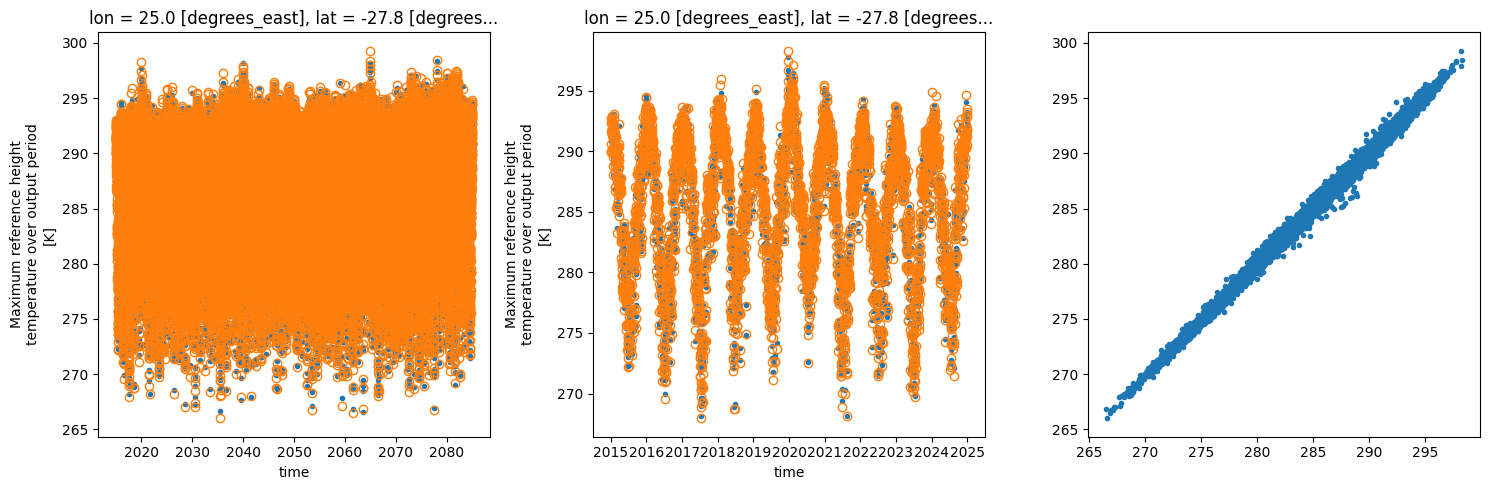

In [95]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
debiased_downscaled_coarsened[:, ix, iy].plot(marker=".", linestyle="none")
coarse_debiased[var][:, ix, iy].plot(marker="o", fillstyle="none", linestyle="none")
plt.subplot(1, 3, 2)
debiased_downscaled_coarsened[:, ix, iy].where(
    debiased_downscaled_coarsened["time.year"] < 2025
).plot(marker=".", linestyle="none")
coarse_debiased[var][:, ix, iy].where(debiased_downscaled_coarsened["time.year"] < 2025).plot(
    marker="o", fillstyle="none", linestyle="none"
)
plt.subplot(1, 3, 3)
plt.plot(
    debiased_downscaled_coarsened[:, ix, iy],
    coarse_debiased[var][:, ix, iy],
    ".",
)
plt.tight_layout()

In 10-year smoothed monthly averages

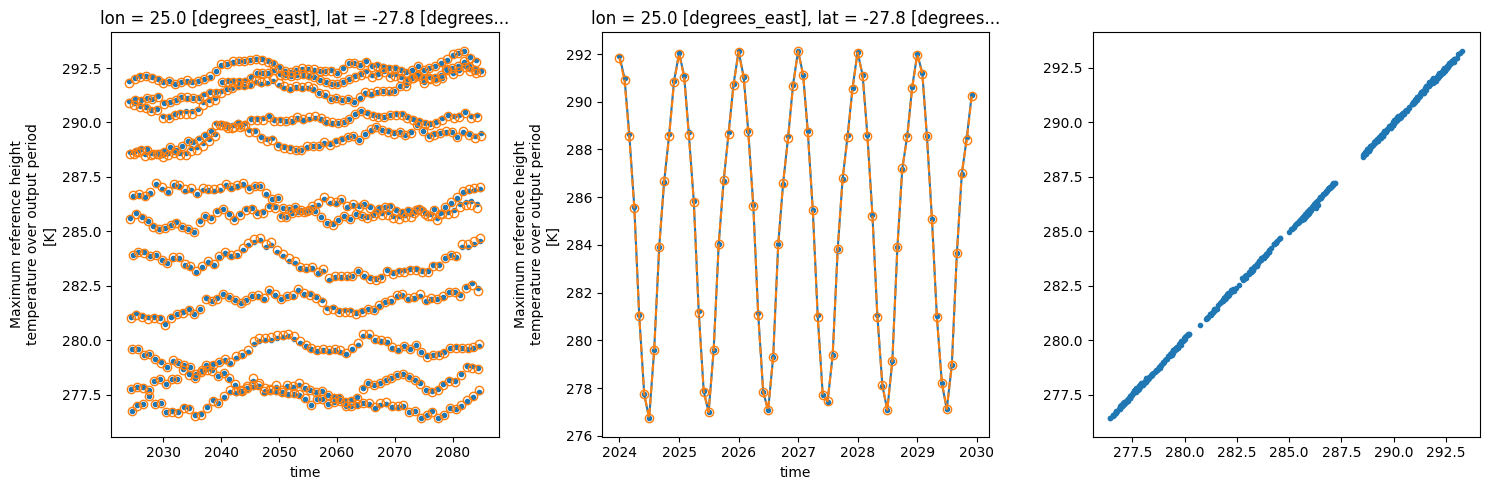

In [96]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
debiased_downscaled_coarsened_monthly_smooth[:, ix, iy].plot(marker=".", linestyle="none")
coarse_debiased_monthly_smooth[:, ix, iy].plot(marker="o", fillstyle="none", linestyle="none")
plt.subplot(1, 3, 2)
debiased_downscaled_coarsened_monthly_smooth[:, ix, iy].where(
    debiased_downscaled_coarsened_monthly_smooth["time.year"] < 2030
).plot(marker=".")
coarse_debiased_monthly_smooth[:, ix, iy].where(
    coarse_debiased_monthly_smooth["time.year"] < 2030
).plot(
    marker="o",
    fillstyle="none",
    linestyle="--",
)
plt.subplot(1, 3, 3)
plt.plot(
    debiased_downscaled_coarsened_monthly_smooth[:, ix, iy],
    coarse_debiased_monthly_smooth[:, ix, iy],
    ".",
)
plt.tight_layout()

### How much does the answer change at all points?

Evaluate the following metrics

* **bias** — mean conservation error over time, per cell. The most important metric here. Should be near zero if the SD step is unbiased on average. A persistent positive or negative value at a cell means the SD step is systematically shifting values in one direction regardless of the day. This is what survives monthly averaging.
* **std_resid** — how much the error varies day to day. Compare to bias: if std_resid >> bias, errors are mostly random and partially cancel in monthly means. If std_resid ~ bias, the error is systematic and monthly averaging won't help.
* **mae** — average absolute error, the typical daily conservation error. More interpretable than RMSE because it's in the same units (K) and isn't dominated by outliers.
* **rmse** — more sensitive to large errors than MAE. If rmse >> mae, there are occasional very large errors on specific days. Compare directly to max_dev to understand the tail.
* **max_dev** — the worst single day across all time steps. This is the 3–5K number you've been seeing. Important for understanding the hard bound on error, but less important if it only occurs on rare extreme days.
* **r2_oneone** (Nash-Sutcliffe efficiency) — the most informative single metric for conservation. NSE = 1 is perfect, NSE = 0 means the downscaled-then-coarsened values are no better than just predicting the long-term mean of the coarse input. NSE < 0 is worse than that. For a conservation check you want this very close to 1. The gap from 1 is explained by SSE / variance(y), so it tells you what fraction of the coarse input's variability is being mis-reproduced.
* **pearson** — will be very close to 1 in almost all cases, because both x and y are driven by the same GCM climate signal. High pearson does NOT mean good conservation — it just means the temporal shape is preserved. The key diagnostic is the difference between pearson and r2_oneone: if pearson ≈ 1 but r2_oneone < 1, the errors are systematic (bias or scaling), not random noise.
* **rmse_perp** — RMSE / √2, the perpendicular distance from the 1:1 line. This is appropriate when neither variable is the "truth" and you want to treat both symmetrically (e.g., in a regression context). Here, y (coarse_debiased) is the truth, so plain RMSE (vertical deviation) is more appropriate. Rmse_perp is less informative for this specific use case.

#### At each timestep

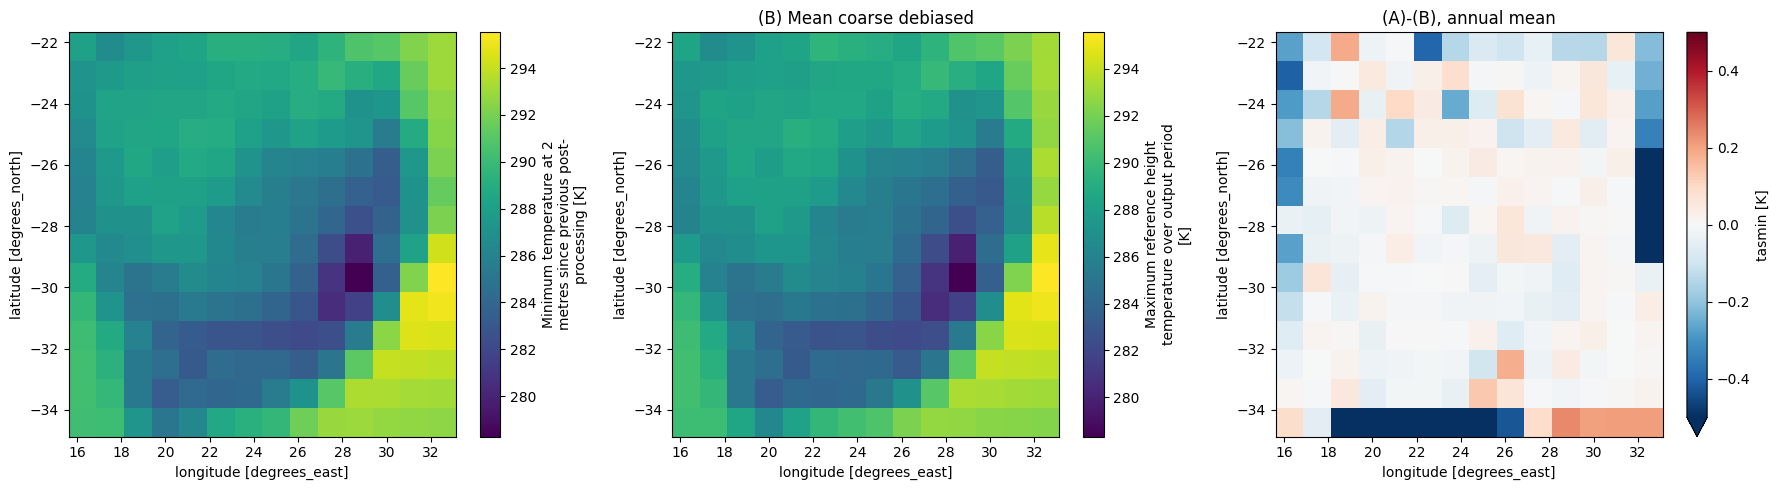

In [97]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.title("(A) Mean re-coarsened debiased, downscaled")
debiased_downscaled_coarsened.mean(dim="time").plot()
plt.subplot(1, 3, 2)
coarse_debiased[var].mean(dim="time").plot()
plt.title("(B) Mean coarse debiased")
plt.subplot(1, 3, 3)
(debiased_downscaled_coarsened.mean(dim="time") - coarse_debiased[var].mean(dim="time")).plot(
    vmax=0.5, vmin=-0.5, cmap=plt.cm.RdBu_r
)
plt.title("(A)-(B), annual mean")
plt.tight_layout()

In [98]:
x = debiased_downscaled_coarsened  # (time, lat, lon)
y = coarse_debiased[var]  # (time, lat, lon)

metrics_daily = disagg_test_calculate_metrics(x, y)

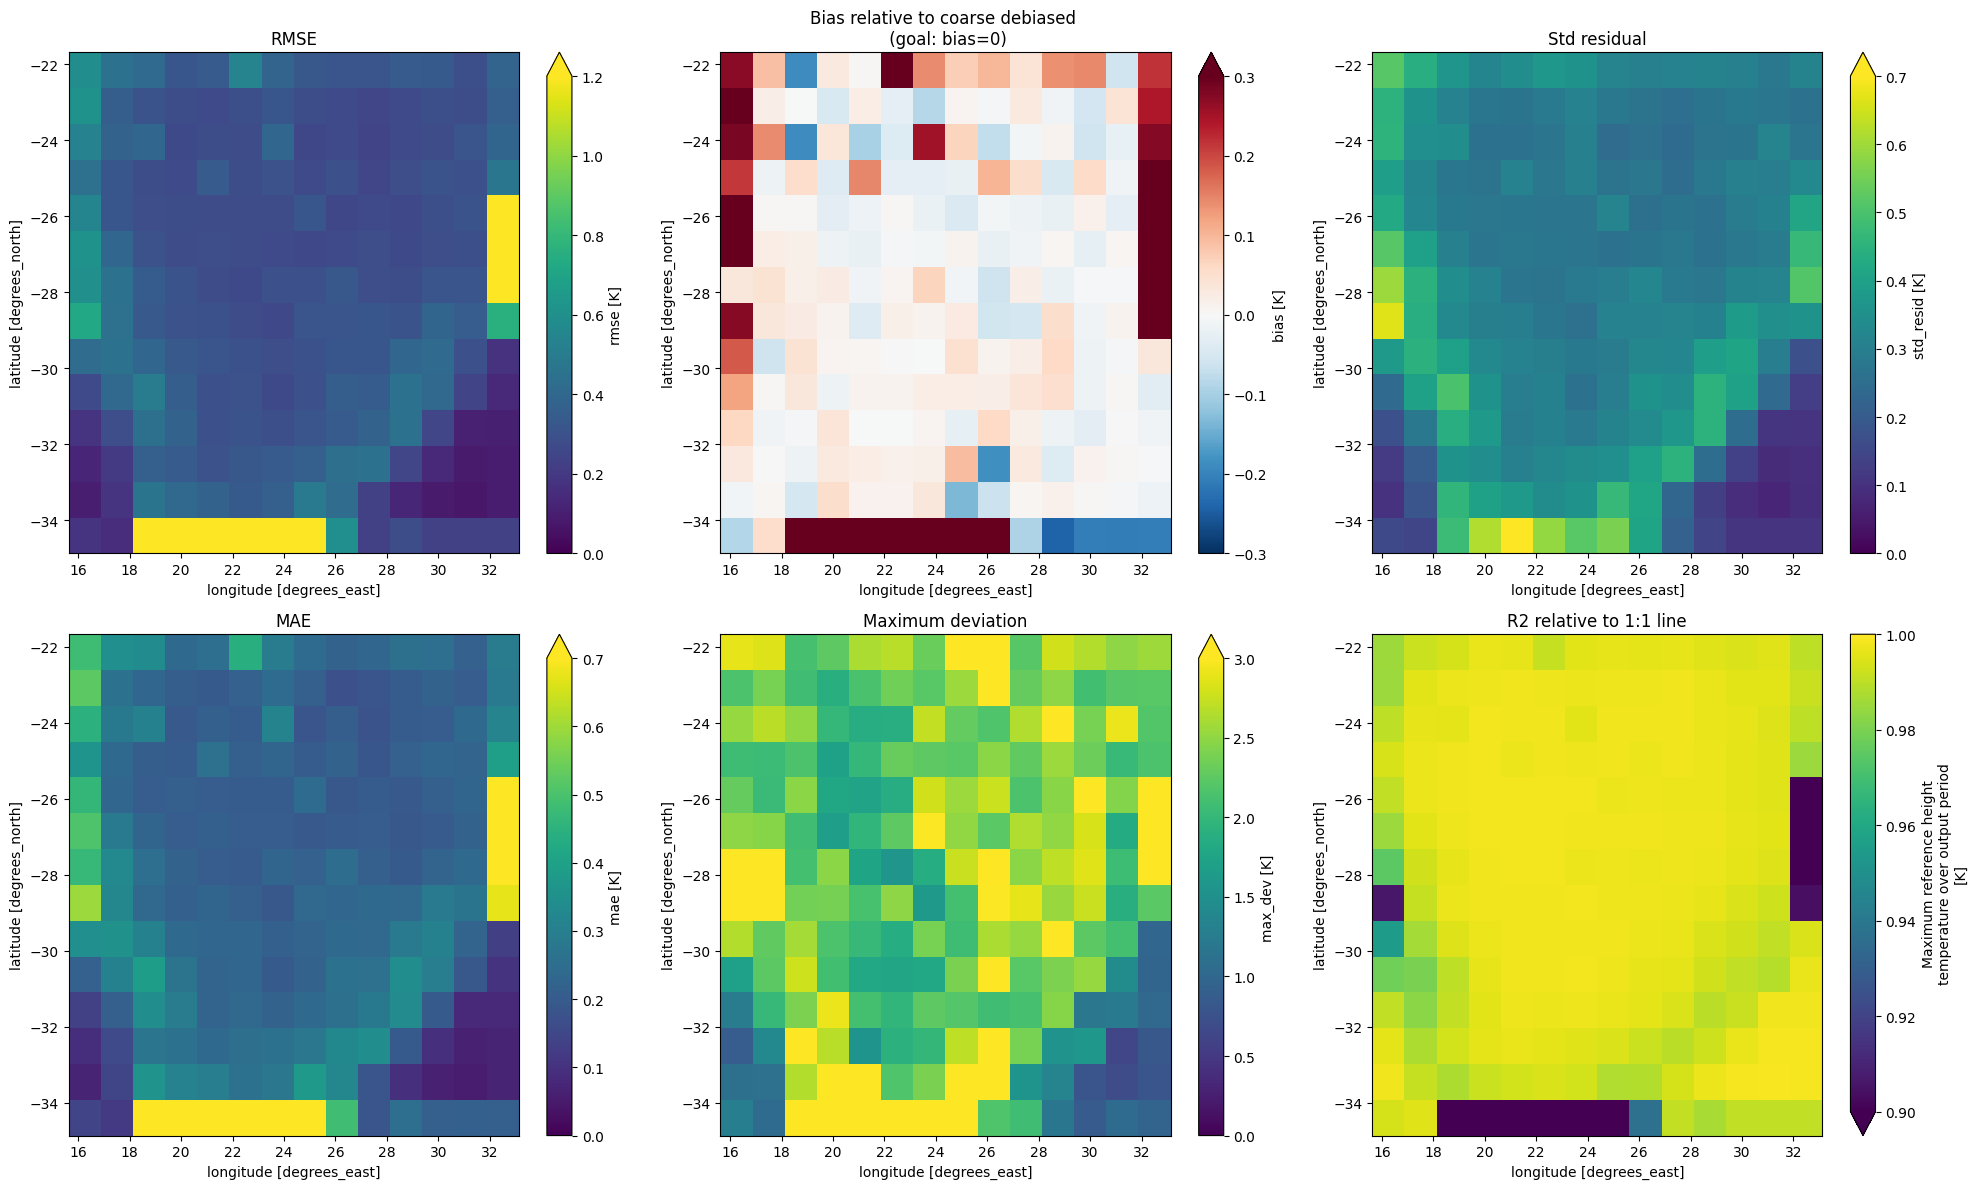

In [99]:
disagg_test_plot_summary_stats(
    metrics_daily,
    vmax_rmse=1.2,
    vmax_bias=0.3,
    vmax_std_resid=0.7,
    vmax_mae=0.7,
    vmax_max_dev=3,
    savefig_path=output_prefix + "_metric_summary" + "_daily" + ".png",
)

In [100]:
disagg_test_print_all_evaluation_metrics(
    metrics=metrics_daily,
    is_regional_subset=True,
    variable=var,
    scenario=scenario,
    ensemble_member=ens,
    timescale="daily",
    log_path=output_prefix + "_daily.csv",
)

---------------rmse---------------
Max:
0.50128484
Min:
0.07254571
Fraction above threshold:
0.006944444444444444
Fraction below threshold:
0.0
---------------bias---------------
Max:
0.25359604
Min:
-0.18769334
Fraction above threshold:
0.027777777777777776
Fraction below threshold:
0.020833333333333332
---------------std_resid---------------
Max:
0.5000725
Min:
0.07238422
Fraction above threshold:
0.006944444444444444
Fraction below threshold:
0.0
---------------mae---------------
Max:
0.38791922
Min:
0.05386162
Fraction above threshold:
0.0
Fraction below threshold:
0.0
---------------max_dev---------------
Max:
20.379364
Min:
0.6281738
Fraction above threshold:
0.9791666666666666
Fraction below threshold:
0.0
---------------r2_oneone---------------
Max:
0.999077
Min:
0.97989684
Fraction above threshold:
0.0
Fraction below threshold:
0.006944444444444444


#### In long term rolling means

In [101]:
x = debiased_downscaled_coarsened_monthly_smooth  # (time, lat, lon)
y = coarse_debiased_monthly_smooth  # (time, lat, lon)

metrics_monthly_smooth = disagg_test_calculate_metrics(x, y)

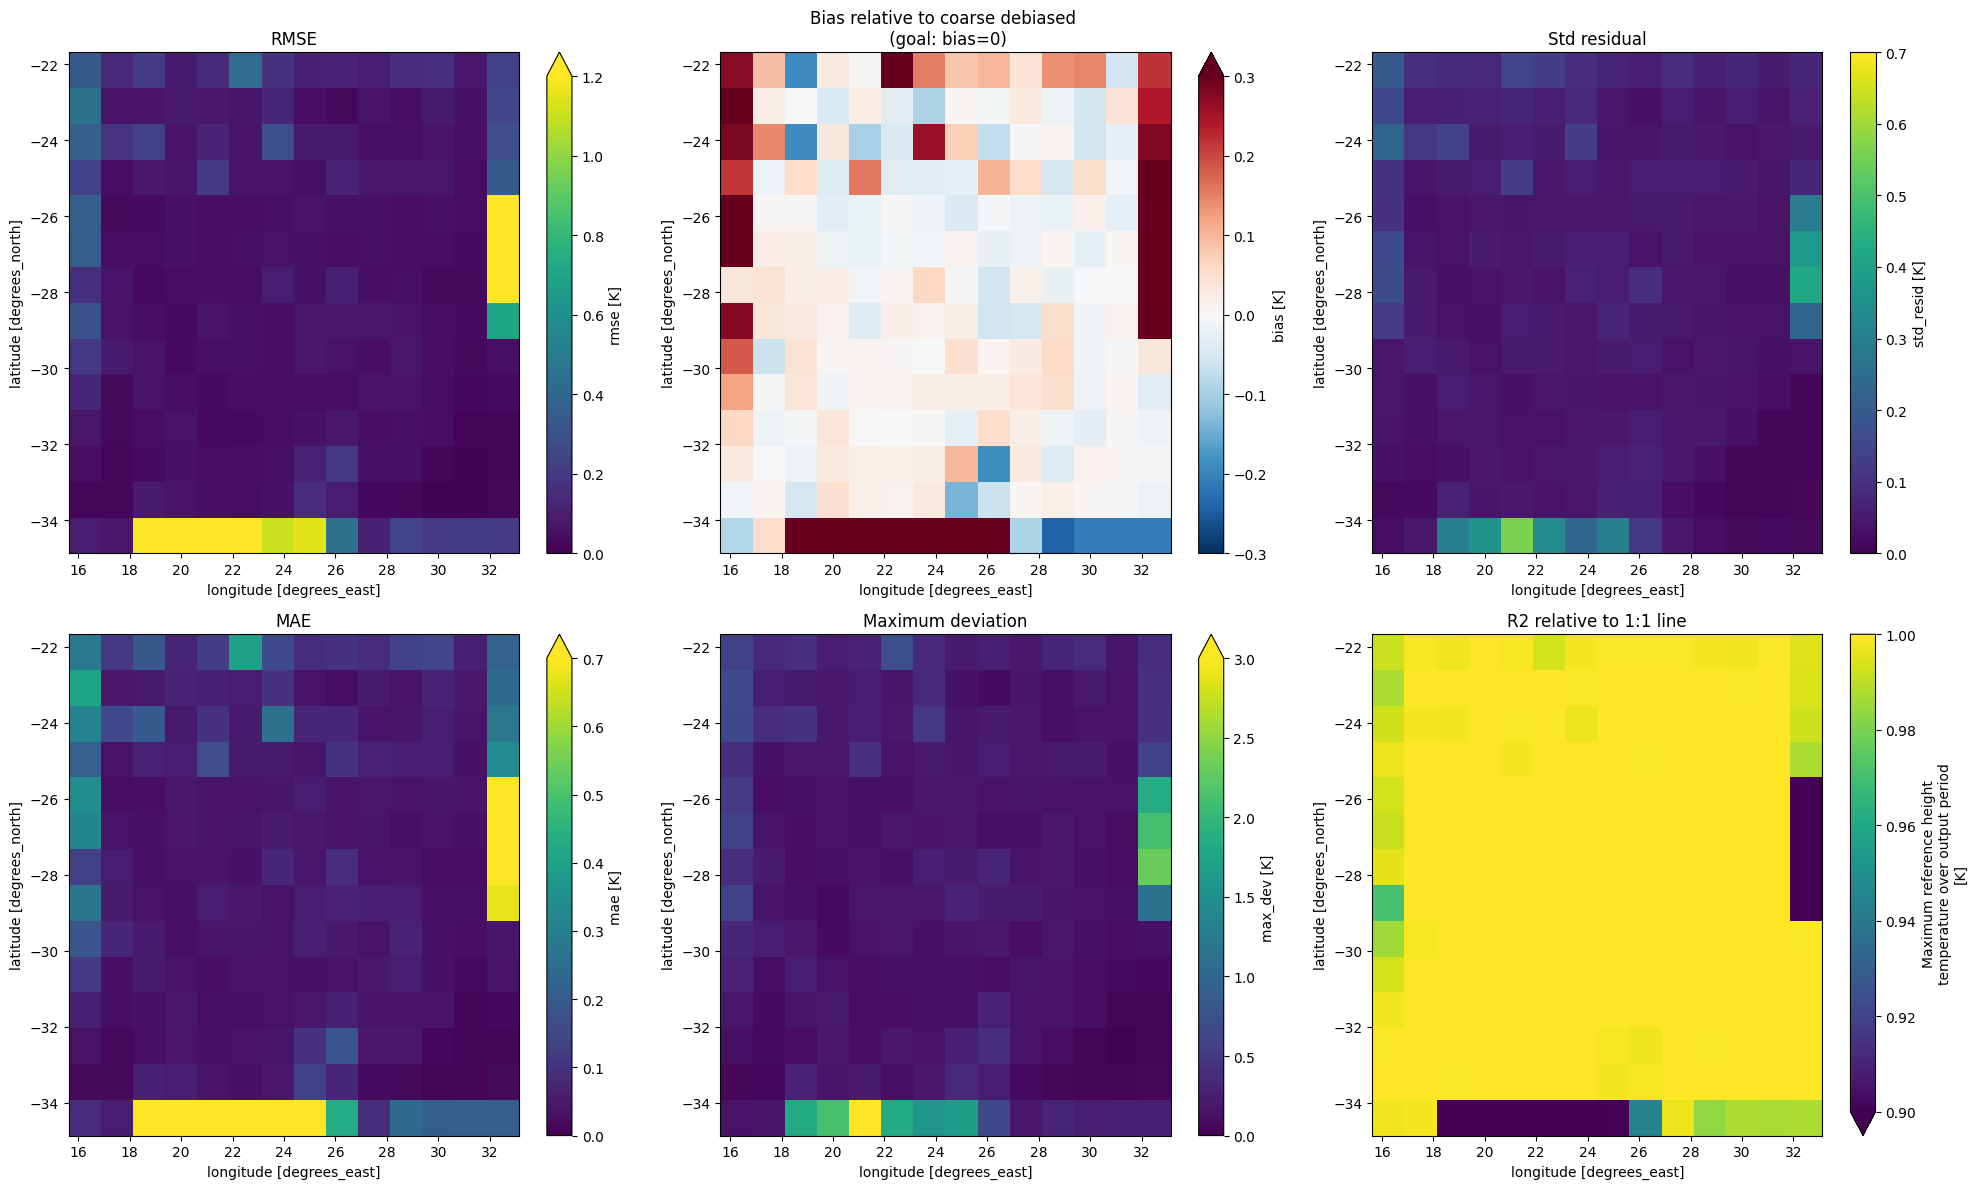

In [102]:
disagg_test_plot_summary_stats(
    metrics_monthly_smooth,
    vmax_rmse=1.2,
    vmax_bias=0.3,
    vmax_std_resid=0.7,
    vmax_mae=0.7,
    vmax_max_dev=3,
    savefig_path=output_prefix + "_metric_summary" + "_monthly_smooth" + ".png",
)

In [103]:
disagg_test_print_all_evaluation_metrics(
    metrics=metrics_monthly_smooth,
    is_regional_subset=True,
    variable=var,
    scenario=scenario,
    ensemble_member=ens,
    timescale="monthly_smooth",
    log_path=output_prefix + "_monthly_smooth.csv",
)

---------------rmse---------------
Max:
0.28872538
Min:
0.0075313933
Fraction above threshold:
0.0
Fraction below threshold:
0.0
---------------bias---------------
Max:
0.25862473
Min:
-0.18897131
Fraction above threshold:
0.027777777777777776
Fraction below threshold:
0.027777777777777776
---------------std_resid---------------
Max:
0.13823658
Min:
0.0064091855
Fraction above threshold:
0.0
Fraction below threshold:
0.0
---------------mae---------------
Max:
0.25947955
Min:
0.006061575
Fraction above threshold:
0.0
Fraction below threshold:
0.0
---------------max_dev---------------
Max:
0.47247314
Min:
0.021850586
Fraction above threshold:
0.0
Fraction below threshold:
0.0
---------------r2_oneone---------------
Max:
0.99998415
Min:
0.99713963
Fraction above threshold:
0.0
Fraction below threshold:
0.0


# 1. Loop through all variables, scenarios, and ensemble members in test

In [104]:
path_output = (
    "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"

In [105]:
var_list = ["tas", "tasmax", "tasmin", "tas", "tasmax", "tasmin", "tas", "tasmax", "tasmin"]
scenario_list = [
    "historical",
    "historical",
    "historical",
    "g6_1p5k",
    "g6_1p5k",
    "g6_1p5k",
    "ssp245",
    "ssp245",
    "ssp245",
]
ens_list = ["r3i1p1f1", "001", "001", "003", "003", "003", "008", "008", "008"]

######################################################
tasmax
g6_1p5k
003
######################################################
---------------rmse---------------
Max:
0.79768795
Min:
0.06296102
Fraction above threshold:
0.16666666666666666
Fraction below threshold:
0.0
---------------bias---------------
Max:
0.06268024
Min:
-0.08038719
Fraction above threshold:
0.0
Fraction below threshold:
0.0
---------------std_resid---------------
Max:
0.79767734
Min:
0.06294904
Fraction above threshold:
0.1597222222222222
Fraction below threshold:
0.0
---------------mae---------------
Max:
0.6420865
Min:
0.046545275
Fraction above threshold:
0.05555555555555555
Fraction below threshold:
0.0
---------------max_dev---------------
Max:
9.932861
Min:
0.61083984
Fraction above threshold:
0.9791666666666666
Fraction below threshold:
0.0
---------------r2_oneone---------------
Max:
0.9992204
Min:
0.9606451
Fraction above threshold:
0.0
Fraction below threshold:
0.0625
---------------rmse---------------


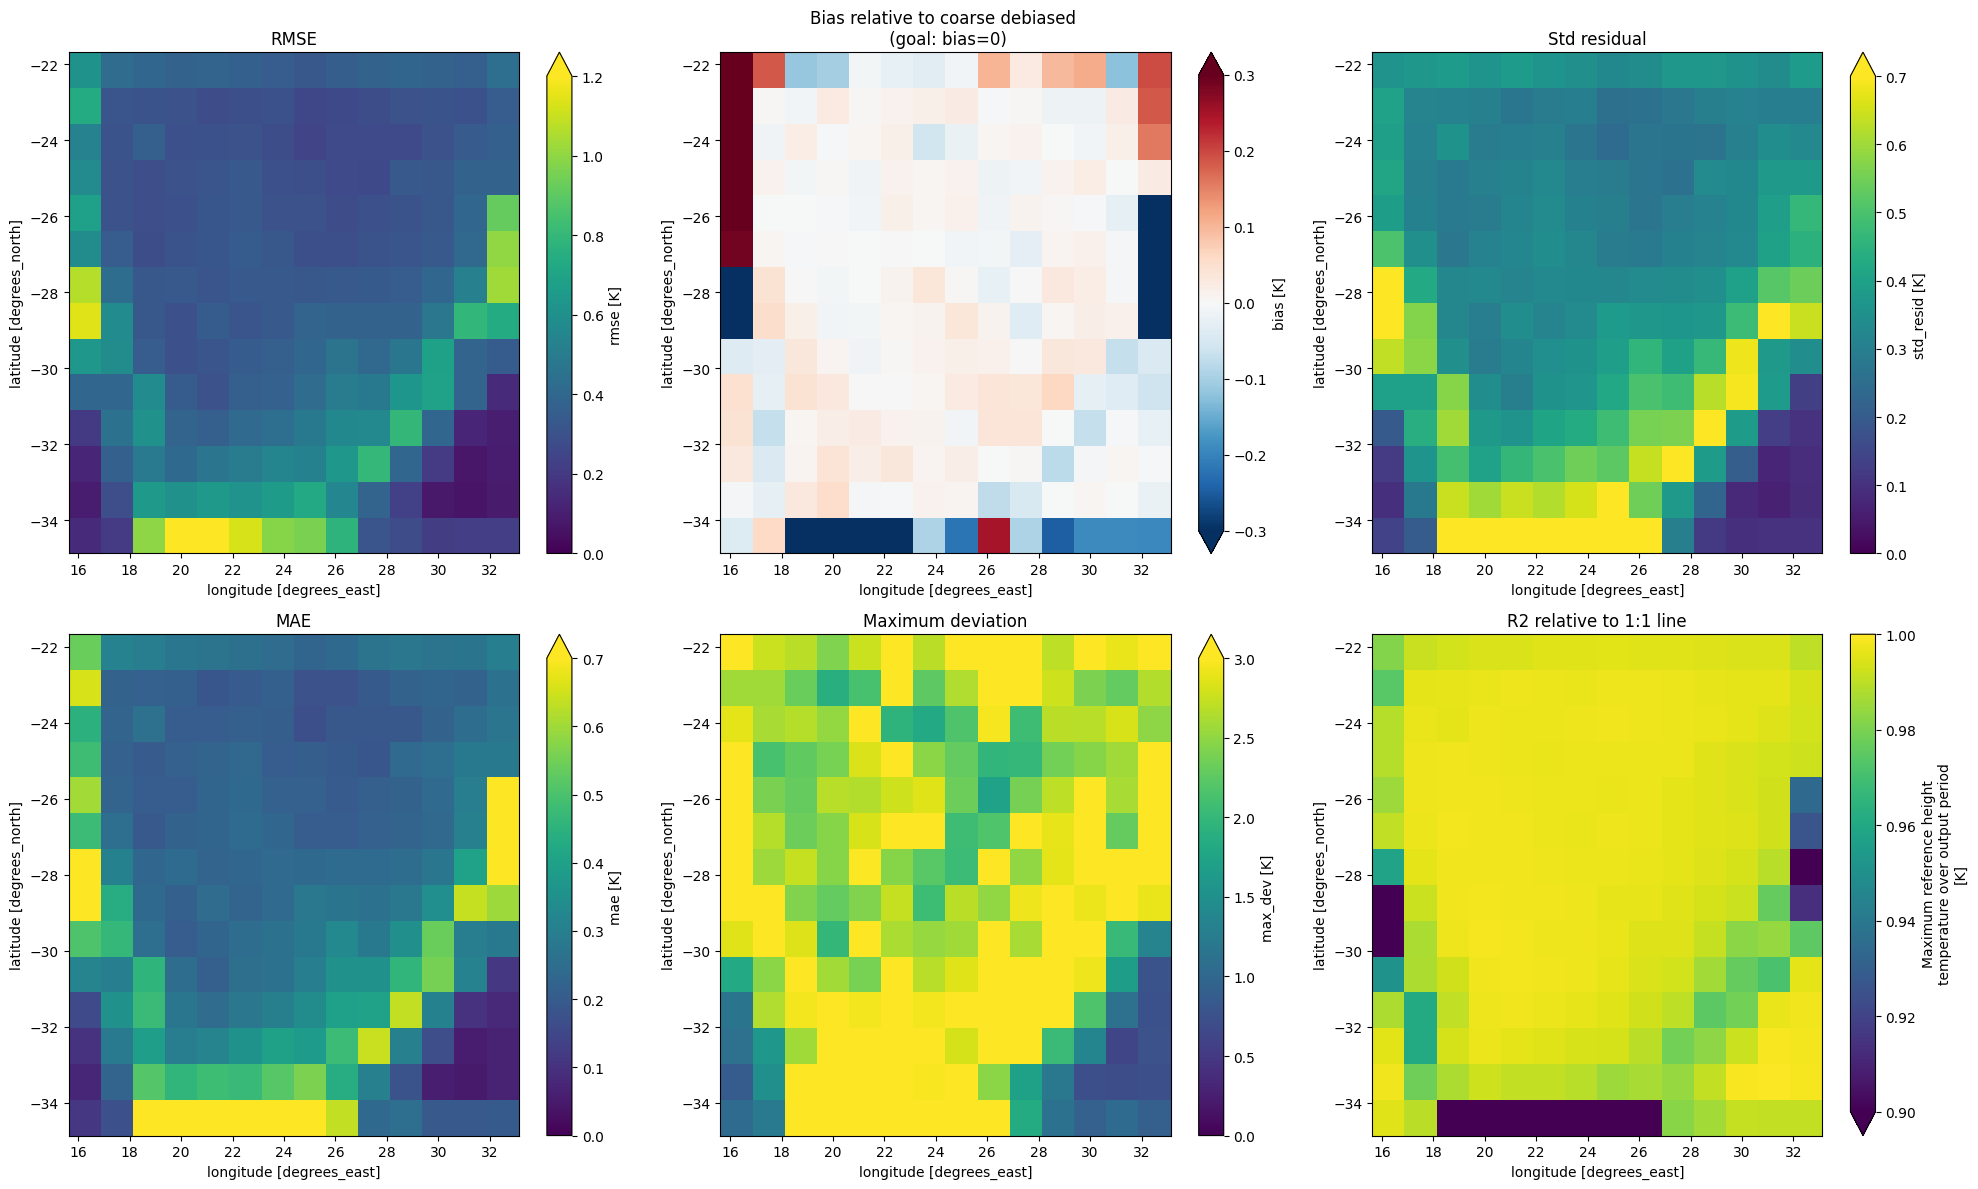

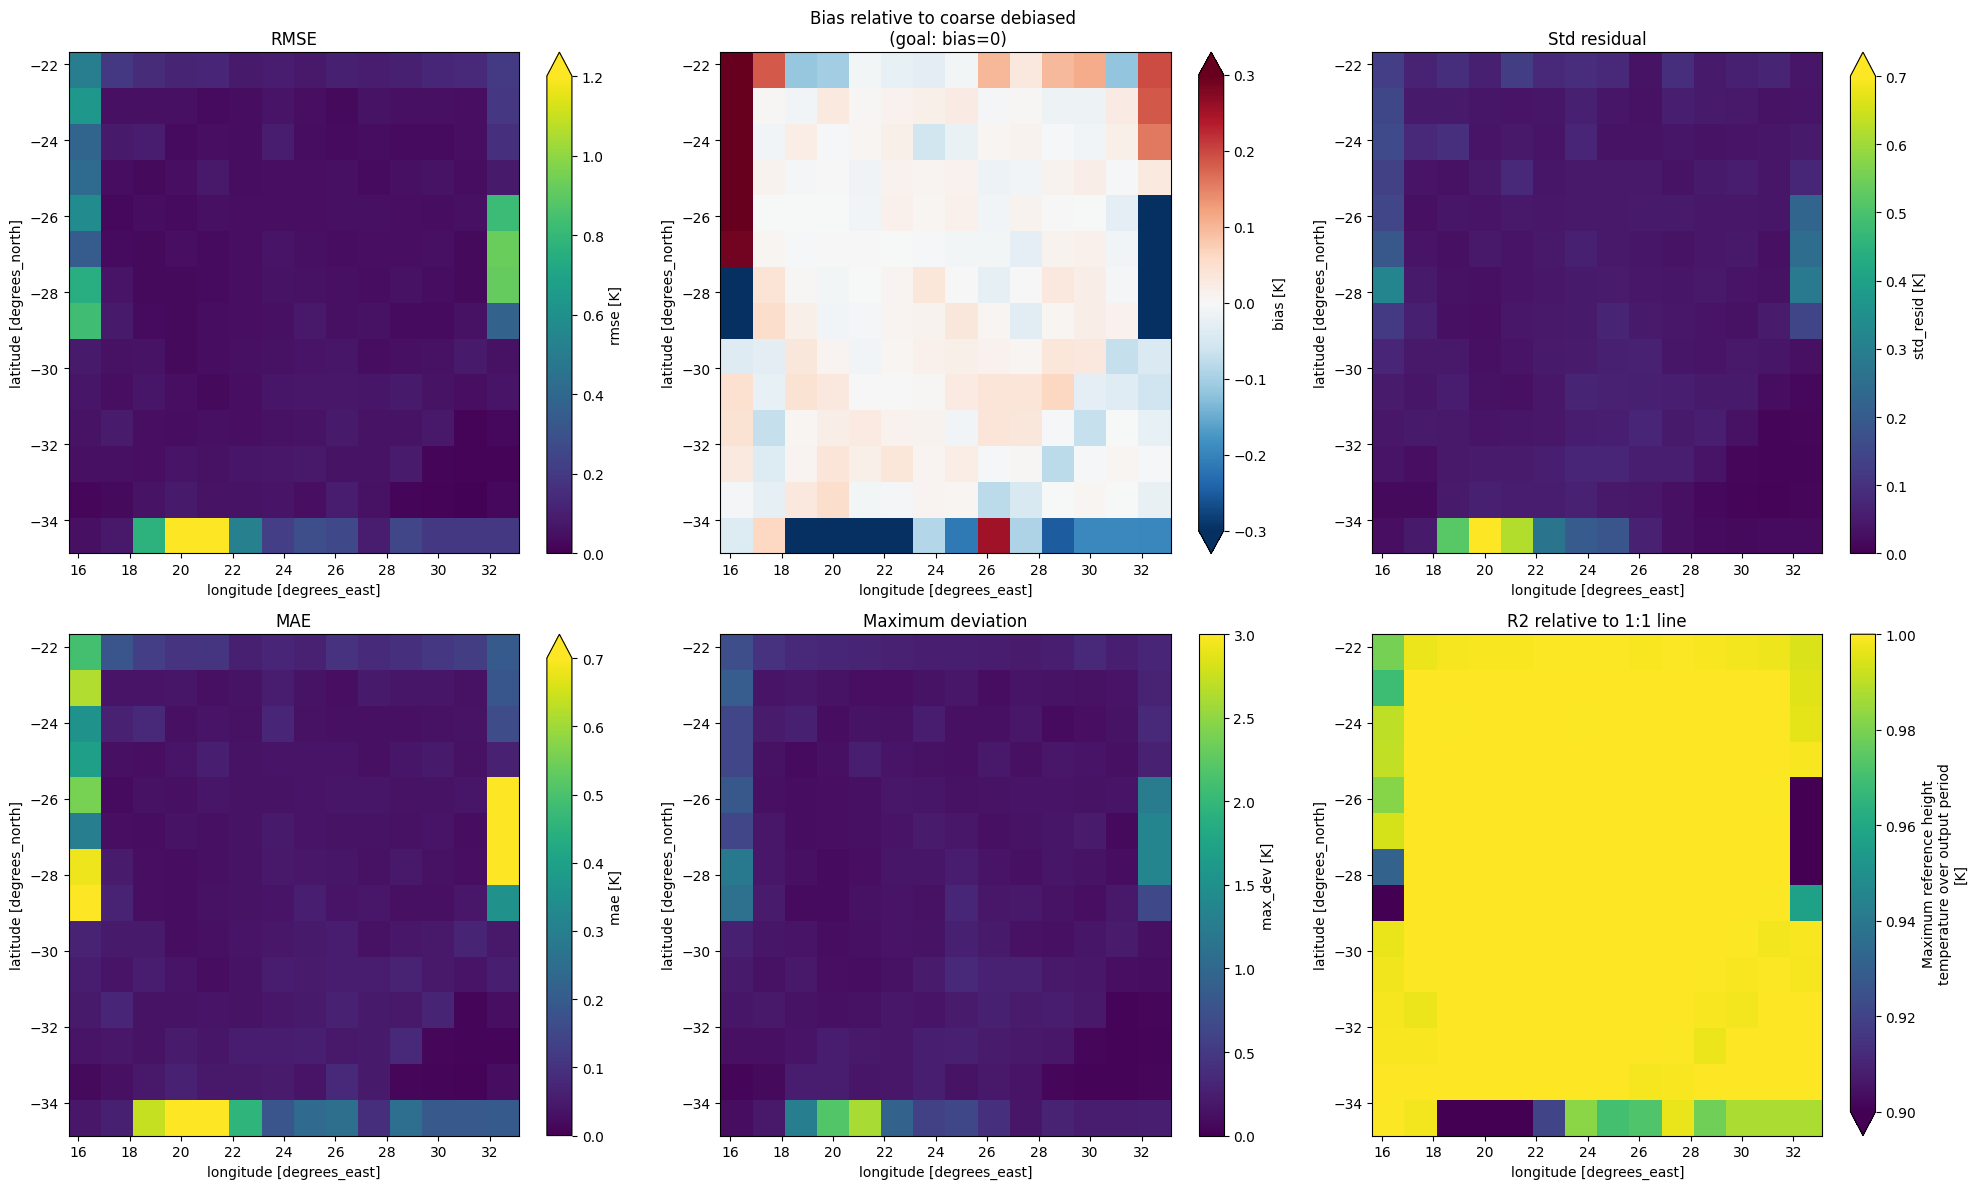

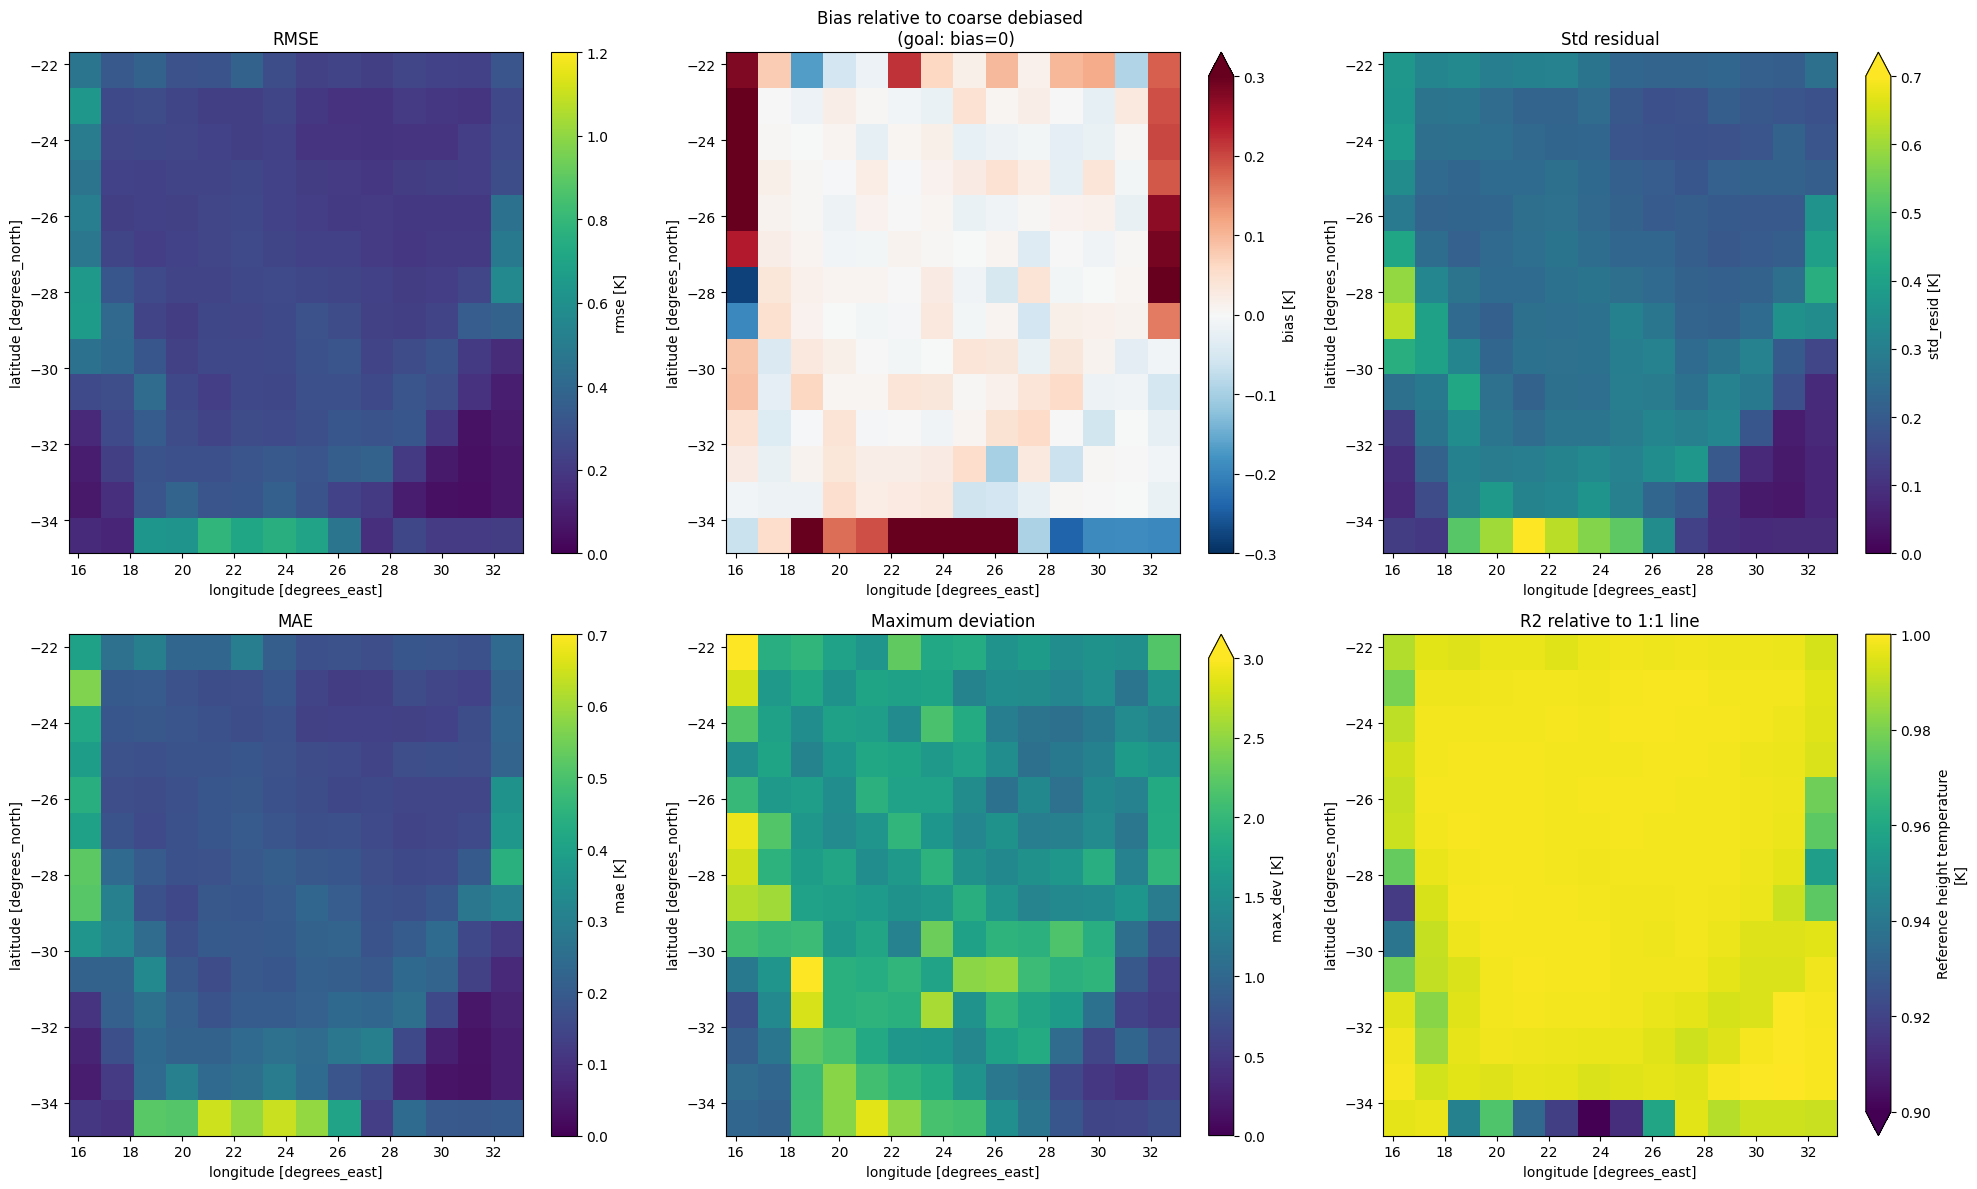

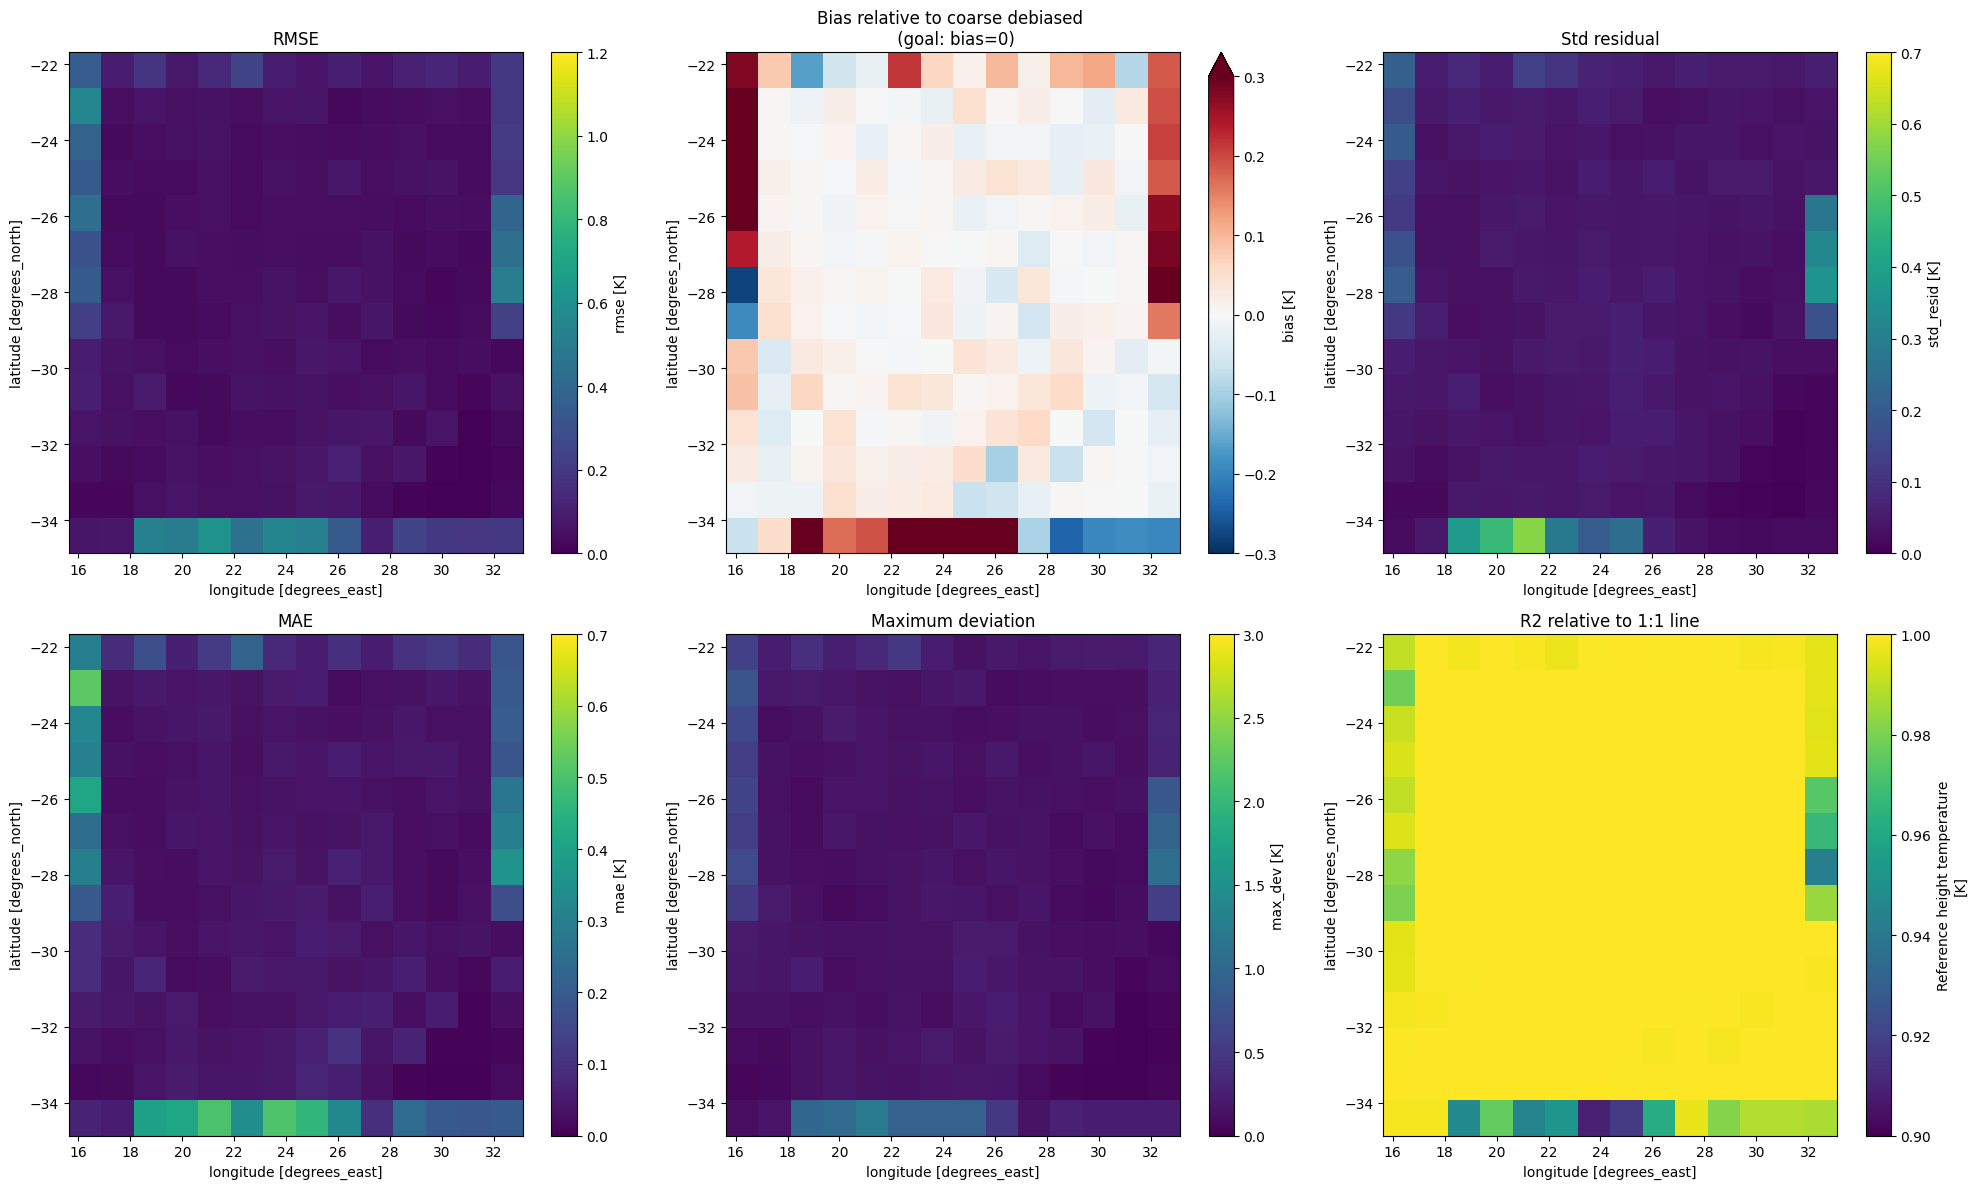

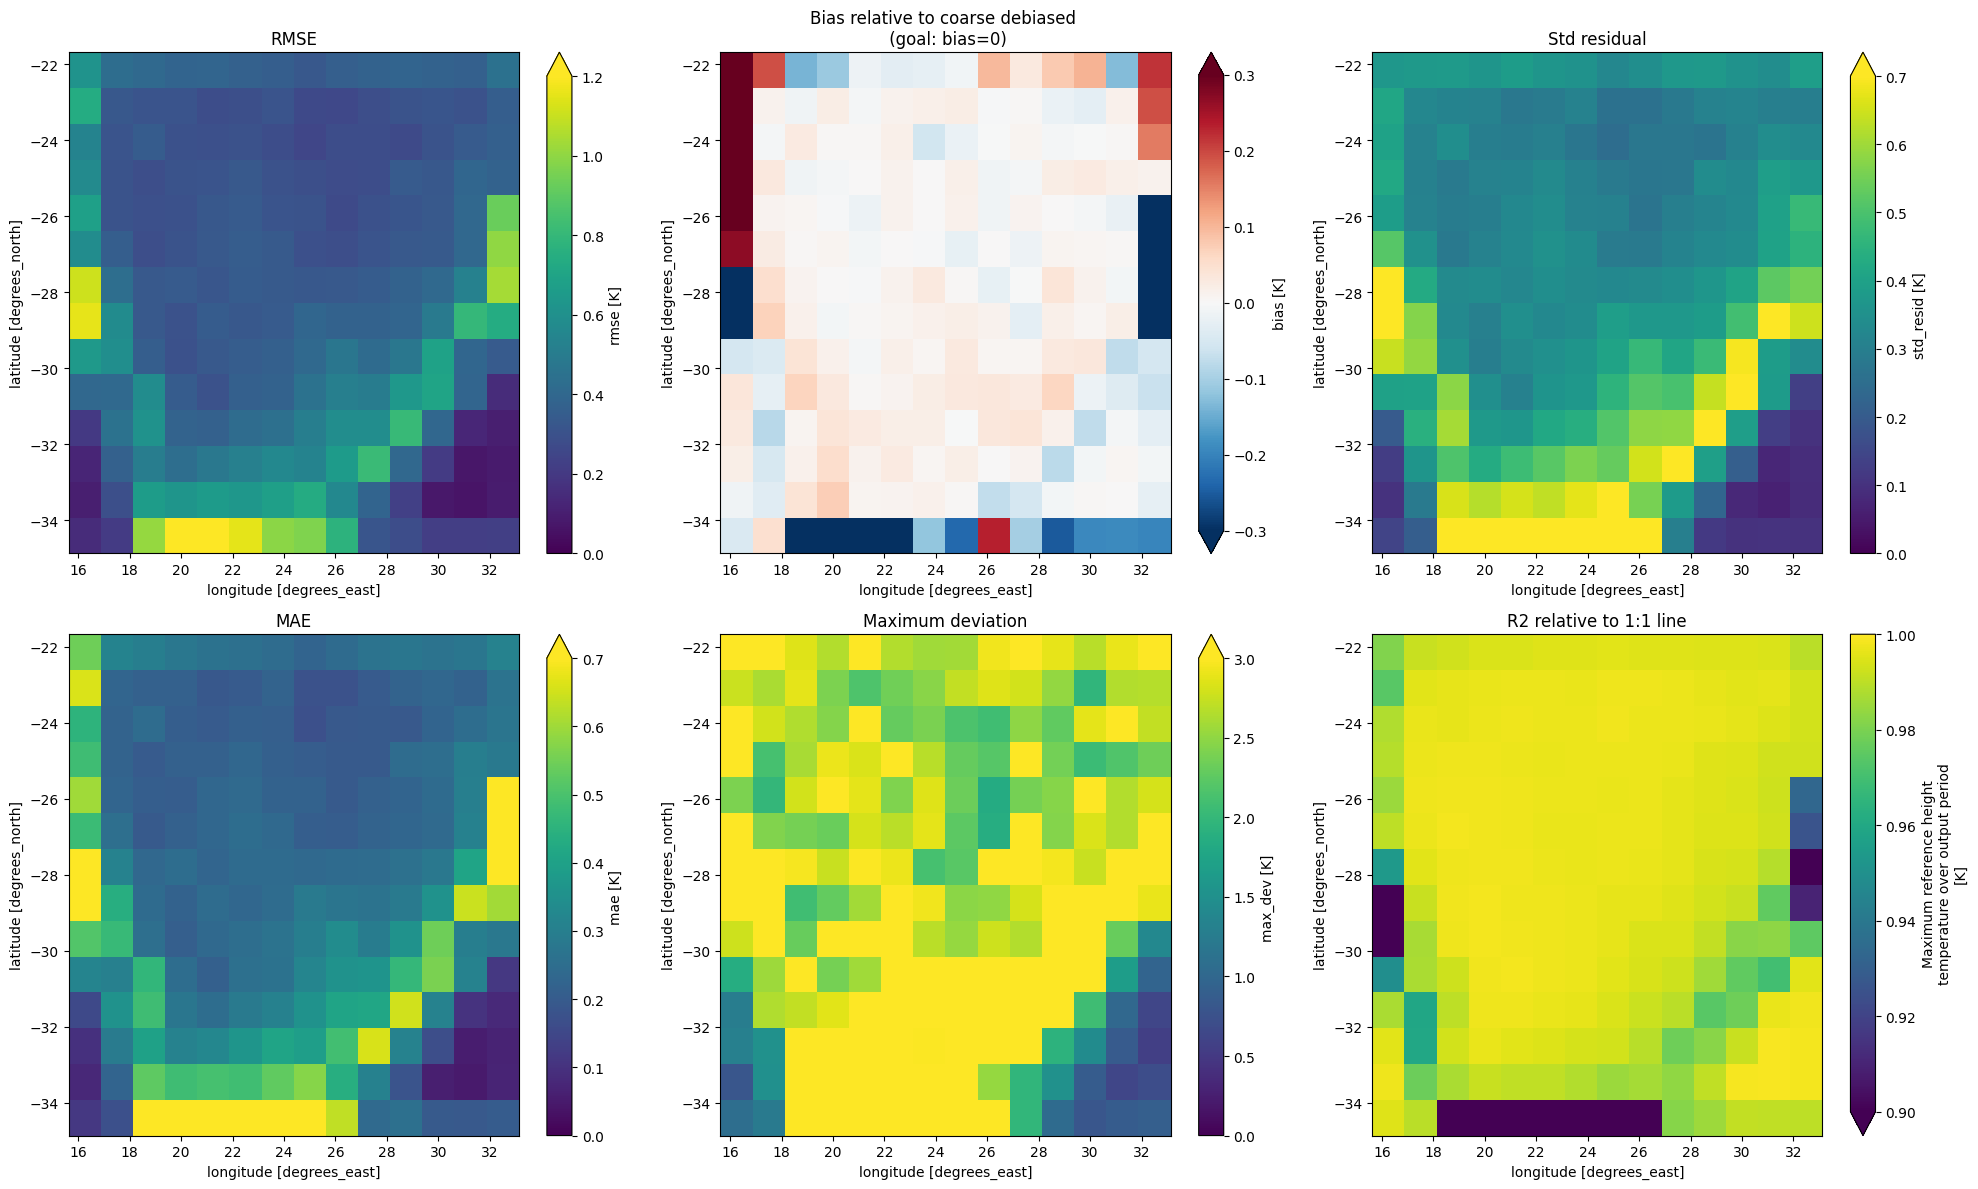

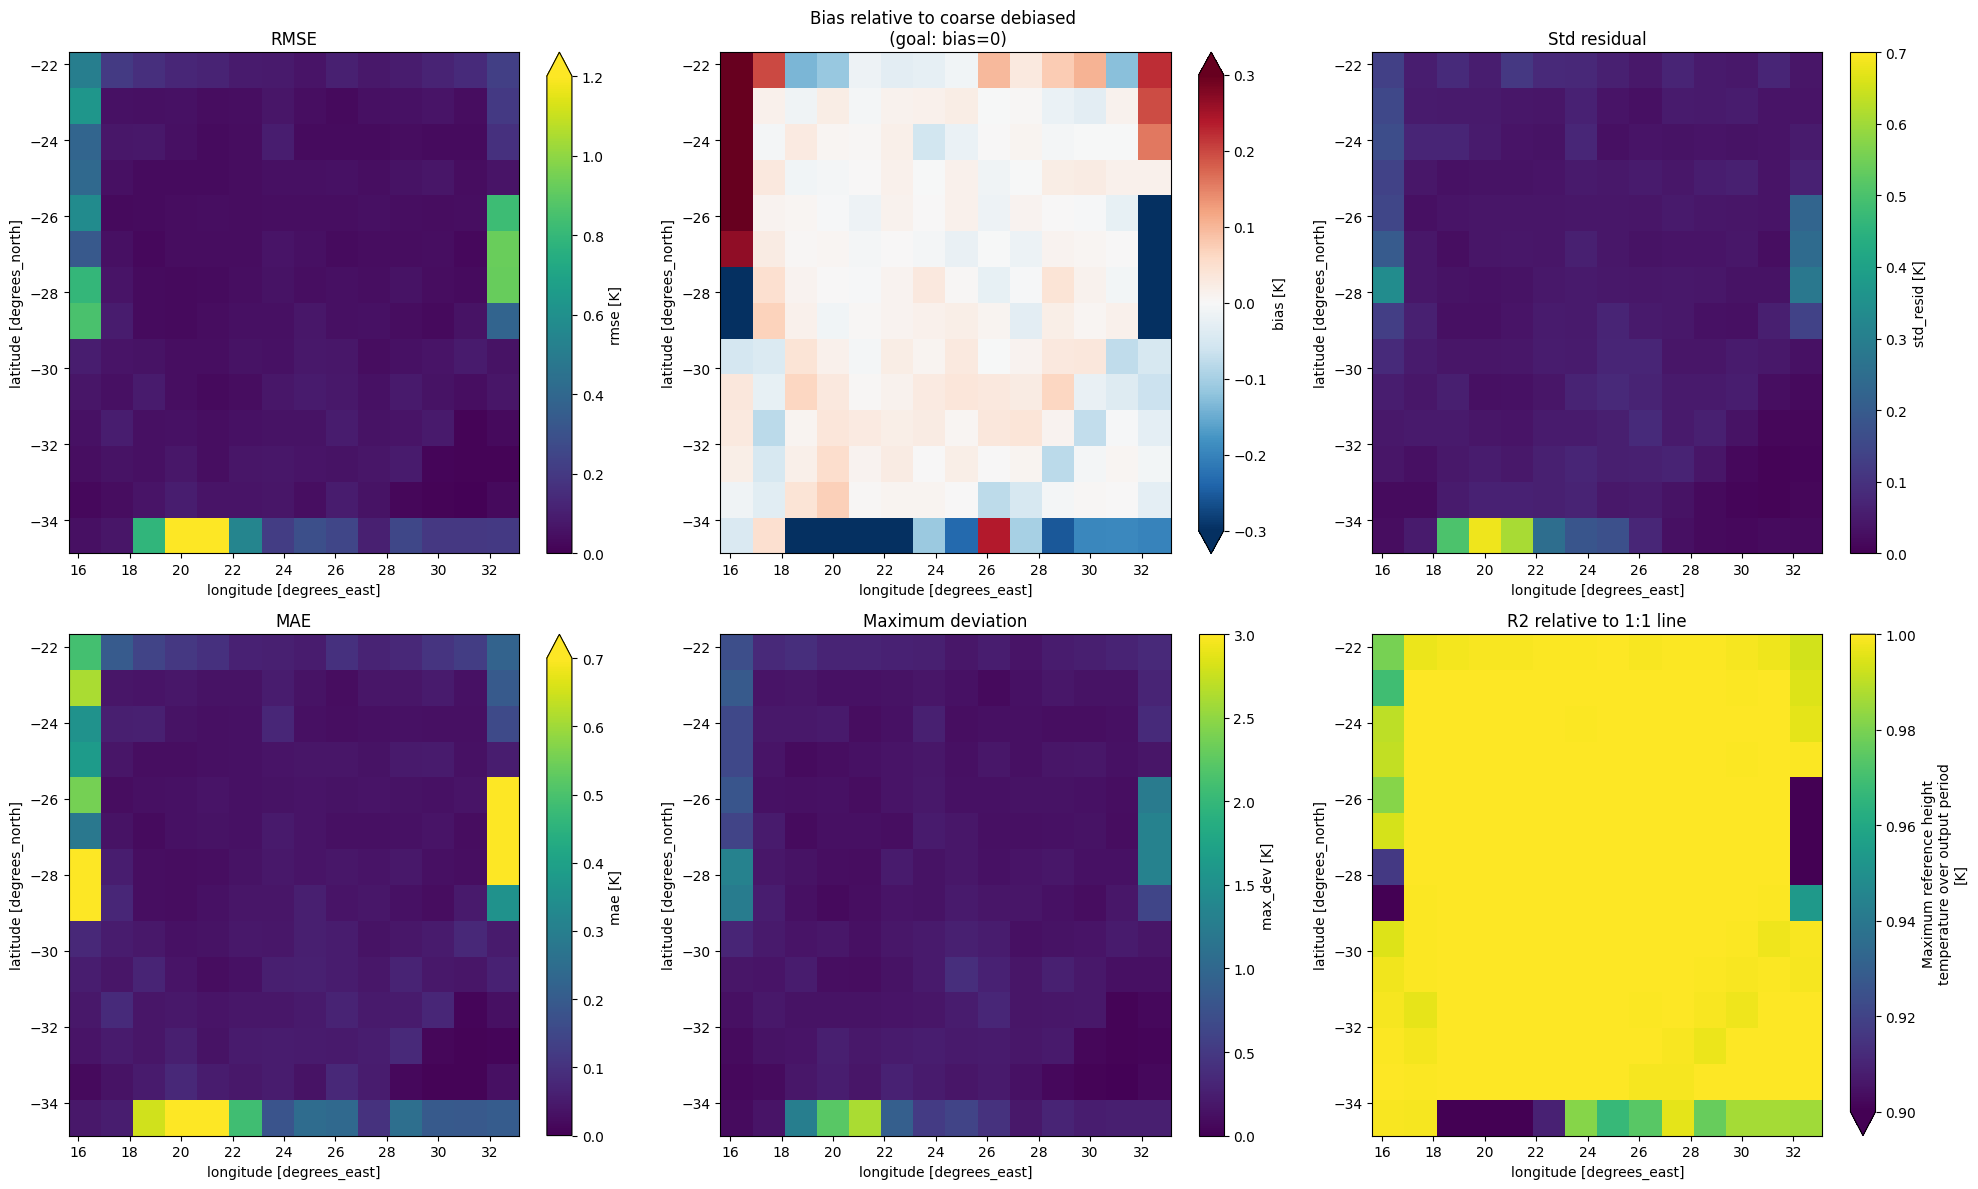

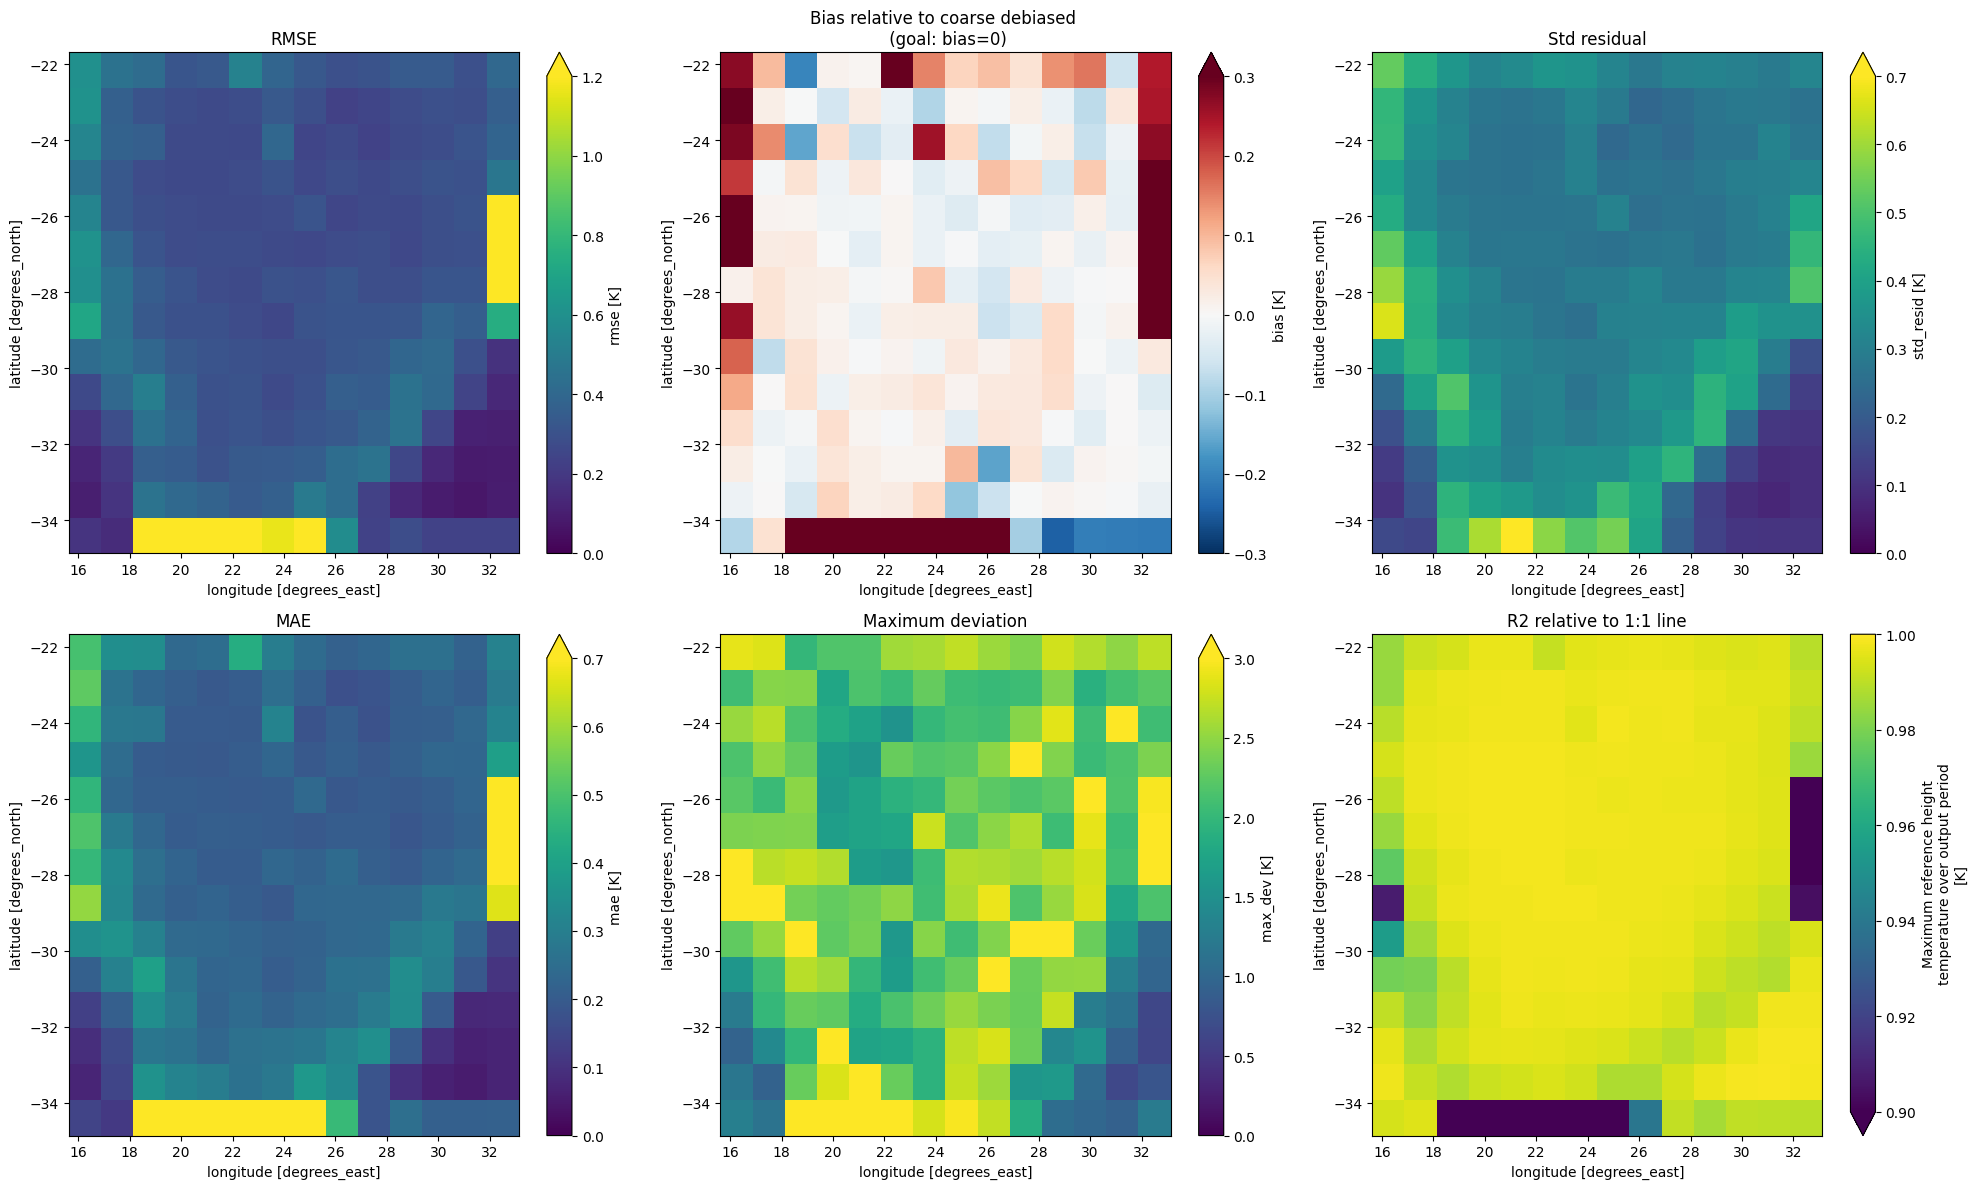

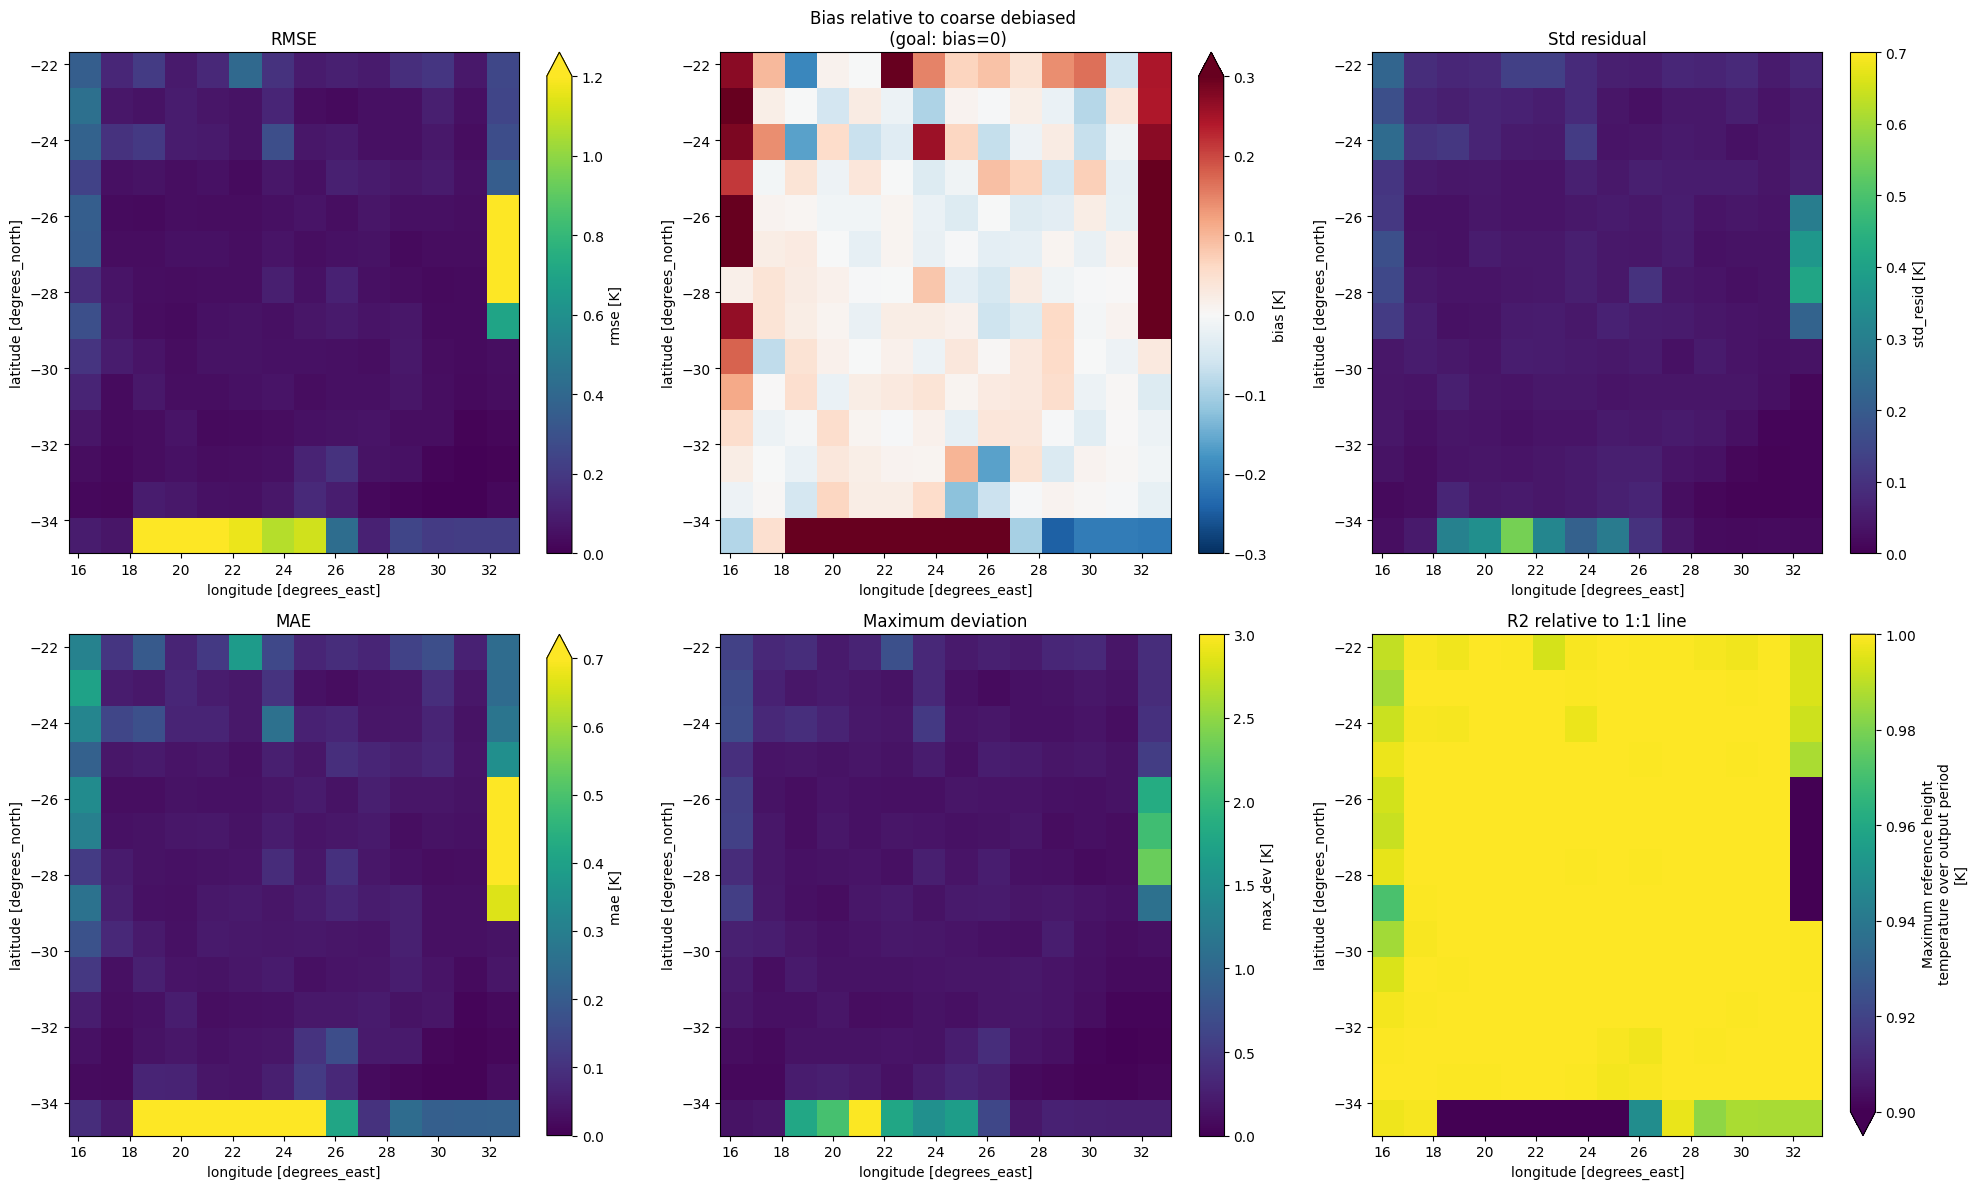

In [106]:
for i, var in enumerate(var_list):
    scenario = scenario_list[i]
    ens = ens_list[i]

    print("######################################################")
    print(var)
    print(scenario)
    print(ens)
    print("######################################################")

    ####### Get data
    coarse_debiased = open_icechunk(
        path=path_output,
        branch="qa-qc-downscaling-step/vtest01",
        group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
    )
    debiased_downscaled = open_icechunk(
        path=path_output,
        branch="qa-qc-downscaling-step/vtest01",
        group=scenario + "/" + var + "/" + ens,
    )

    output_prefix = path_qaqc + "disagg_tests_" + var + "_" + scenario + "_" + ens

    ####### Process data
    debiased_downscaled_coarsened = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=debiased_downscaled[var], da_coarse_grid=coarse_debiased[var]
    )

    # Look at 10-year rolling average of monthly means
    # Coarsened debiased downscaled
    monthly = debiased_downscaled_coarsened.resample(time="MS").mean()
    debiased_downscaled_coarsened_monthly_smooth = (
        monthly.groupby("time.month")
        .map(lambda da: da.rolling(time=10, min_periods=10).mean())
        .sortby("time")
    )

    # Coarse debiased
    monthly = coarse_debiased[var].resample(time="MS").mean()

    coarse_debiased_monthly_smooth = (
        monthly.groupby("time.month")
        .map(lambda da: da.rolling(time=10, min_periods=10).mean())
        .sortby("time")
    )

    ####### Calculate comparison metrics and make plots
    x = debiased_downscaled_coarsened  # (time, lat, lon)
    y = coarse_debiased[var]  # (time, lat, lon)

    metrics_daily = disagg_test_calculate_metrics(x, y)

    disagg_test_plot_summary_stats(
        metrics_daily,
        vmax_rmse=1.2,
        vmax_bias=0.3,
        vmax_std_resid=0.7,
        vmax_mae=0.7,
        vmax_max_dev=3,
        savefig_path=output_prefix + "_metric_summary" + "_daily" + ".png",
    )

    disagg_test_print_all_evaluation_metrics(
        metrics=metrics_daily,
        is_regional_subset=True,
        variable=var,
        scenario=scenario,
        ensemble_member=ens,
        timescale="daily",
        log_path=output_prefix + "_daily.csv",
    )

    x = debiased_downscaled_coarsened_monthly_smooth  # (time, lat, lon)
    y = coarse_debiased_monthly_smooth  # (time, lat, lon)

    metrics_monthly_smooth = disagg_test_calculate_metrics(x, y)

    disagg_test_plot_summary_stats(
        metrics_monthly_smooth,
        vmax_rmse=1.2,
        vmax_bias=0.3,
        vmax_std_resid=0.7,
        vmax_mae=0.7,
        vmax_max_dev=3,
        savefig_path=output_prefix + "_metric_summary" + "_monthly_smooth" + ".png",
    )

    disagg_test_print_all_evaluation_metrics(
        metrics=metrics_monthly_smooth,
        is_regional_subset=True,
        variable=var,
        scenario=scenario,
        ensemble_member=ens,
        timescale="monthly_smooth",
        log_path=output_prefix + "_monthly_smooth.csv",
    )

### combine csvs

In [116]:
dfs = [pd.read_csv(p) for p in glob.glob("/scratch/synced/qa_plots/disagg_checks/*.csv")]
combined = pd.concat(dfs, ignore_index=True)
combined.to_csv("/scratch/synced/qa_plots/disagg_checks/all_sims.csv", index=False)

In [117]:
combined

,variable,scenario,ensemble_member,timescale,metric,max,min,fraction_above,fraction_below
0,tasmax,historical,1,monthly_smooth,rmse,0.059093,0.004509,0.0,0.0
1,tasmax,historical,1,monthly_smooth,bias,0.006823,-0.027353,0.0,0.0
2,tasmax,historical,1,monthly_smooth,std_resid,0.059092,0.004427,0.0,0.0
3,tasmax,historical,1,monthly_smooth,mae,0.045715,0.003638,0.0,0.0
4,tasmax,historical,1,monthly_smooth,max_dev,0.202881,0.013306,0.0,0.0
...,...,...,...,...,...,...,...,...,...
127,tasmin,historical,1,monthly_smooth,bias,0.027652,-0.012668,0.0,0.0
128,tasmin,historical,1,monthly_smooth,std_resid,0.103949,0.004888,0.0,0.0
129,tasmin,historical,1,monthly_smooth,mae,0.084462,0.003861,0.0,0.0
130,tasmin,historical,1,monthly_smooth,max_dev,0.246124,0.014893,0.0,0.0
